# Travel Planning Workflow - Evaluation

Evaluate agent responses from a multi-agent travel planning workflow using Azure AI evaluators.

## Prerequisites

Install required packages:
```bash
pip install matplotlib networkx python-dotenv
pip install azure-ai-projects --extra-index-url https://pkgs.dev.azure.com/azure-sdk/public/_packaging/azure-sdk-for-python/pypi/simple --pre --force-reinstall
```

Set environment variables in `.env`:
```
AZURE_AI_PROJECT_ENDPOINT=your_endpoint
AZURE_AI_MODEL_DEPLOYMENT_NAME=gpt-4o-mini
```

In [1]:
import json
import os
import time
from pprint import pprint
from dotenv import load_dotenv
from azure.ai.projects import AIProjectClient
from azure.identity import DefaultAzureCredential
import matplotlib.pyplot as plt
import networkx as nx

load_dotenv()

project_client = AIProjectClient(
    endpoint=os.environ["AZURE_AI_PROJECT_ENDPOINT"],
    credential=DefaultAzureCredential(),
    api_version="2025-11-15-preview"
)
openai_client = project_client.get_openai_client()
print("✓ Connected to Azure AI Project")

✓ Connected to Azure AI Project


## Step 1: Run Workflow

Execute the multi-agent travel planning workflow. This generates response IDs that will be used for evaluation.

The workflow structure is as follows (Image generated by Copilot :)):

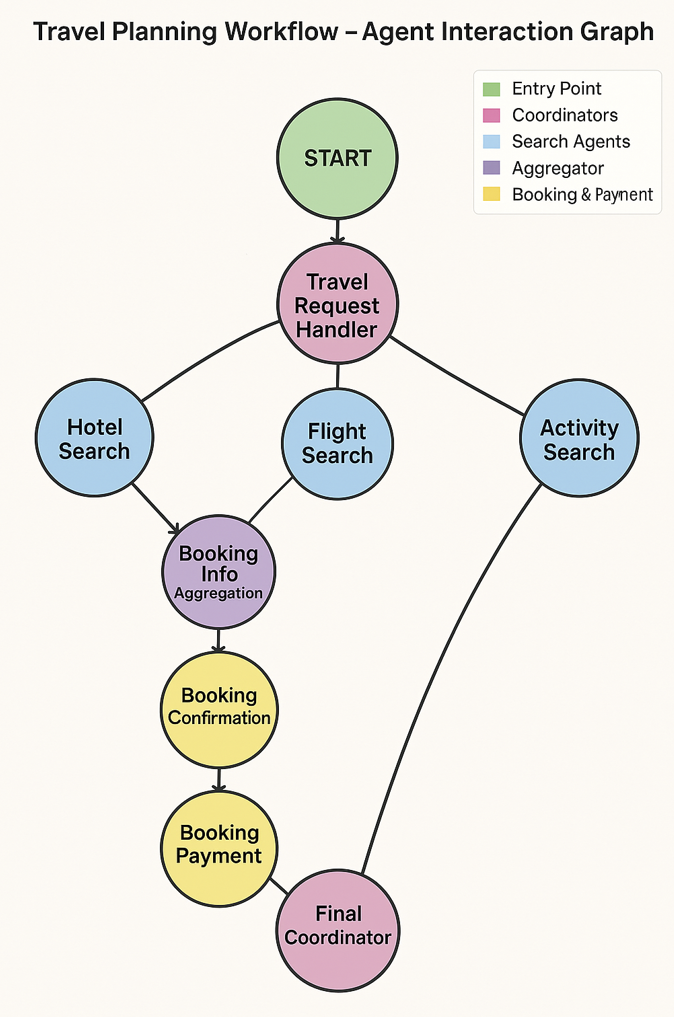

In [3]:
# Run workflow directly by importing and calling the main function
import sys
from pathlib import Path

# Add the workflow directory to path to import the workflow module
workflow_dir = Path.cwd()
if str(workflow_dir) not in sys.path:
    sys.path.insert(0, str(workflow_dir))

# Import and run the workflow
from workflow_evaluation_multi_response import main_async
import asyncio

print("Running travel planning workflow...")
print("It might take a while for the workflow execution to complete...\n")
await main_async()
print("\n✓ Workflow execution completed")

Running travel planning workflow...
It might take a while for the workflow execution to complete...

Query: Plan a 3-day trip to Paris from December 15-18, 2025. Budget is $2000. Need hotel near Eiffel Tower, round-trip flights from New York JFK, and recommend 2-3 activities per day.


Workflow Output: Here's your comprehensive travel plan for your 3-day trip to Paris from December 15-18, 2025, keeping within your budget of $2000.

### **Travel Plan Overview**

- **Destination:** Paris, France
- **Travel Dates:** December 15-18, 2025
- **Budget:** $2000
- **Departure City:** New York (JFK)

---

### **Flights**

**Round-trip Flights from JFK to CDG:**

- **Airline:** American Airlines
- **Departure:** December 15, 2025, 6:20 PM (JFK) -> Arrives December 16 at 7:30 AM (CDG)
- **Return:** December 18, 2025, 2:00 PM (CDG) -> Arrives at 5:30 PM (JFK)
- **Price:** $750 per person = **$1500 for 2 people**

---

### **Hotel Accommodation**

**Hotel Option Near the Eiffel Tower:**

1. **Hôtel 

## Step 2: Load Agent Response IDs

Load workflow results with agent response and conversation IDs.

In [4]:
json_file_path = "workflow_agent_ids_multi_response.json"

with open(json_file_path, 'r', encoding='utf-8') as f:
    workflow_data = json.load(f)

print(f"Query: {workflow_data['query']}\n")
print(f"{'='*80}")
print(f"Available Agents and Their Responses:")
print(f"{'='*80}\n")

for agent_name, agent_data in workflow_data['agents'].items():
    response_count = agent_data['response_count']
    print(f"{agent_name}: {response_count} response(s)")
    if agent_data['response_ids']:
        print(f"  Latest Response ID: {agent_data['response_ids'][-1]}")
    print()

Query: Plan a 3-day trip to Paris from December 15-18, 2025. Budget is $2000. Need hotel near Eiffel Tower, round-trip flights from New York JFK, and recommend 2-3 activities per day.

Available Agents and Their Responses:

booking_payment_agent: 4 response(s)
  Latest Response ID: resp_2b66c38262268029006911cb719590819082e00a16235cff06

travel_request_handler: 1 response(s)
  Latest Response ID: resp_af64ddb80b38933f006911caf4fcd48190989bdf63981f3637

booking_info_aggregation_agent: 2 response(s)
  Latest Response ID: resp_f39754a6ca7d4e37006911cb1ee8588190b6866b9d6eca1f03

hotel_search_agent: 2 response(s)
  Latest Response ID: resp_168df6f59bf679bd006911cb065ec48190af421bf6c7eab0c1

flight_search_agent: 2 response(s)
  Latest Response ID: resp_a2a2aa217ac458fd006911cb09fa008190a404f9c715343c2f

activity_search_agent: 2 response(s)
  Latest Response ID: resp_16a17016c66ff286006911cb0a2b748190a68e60d62ee76d9f

booking_confirmation_agent: 5 response(s)
  Latest Response ID: resp_ba0bb4

## Step 4: Retrieve Final Response per Agent

Fetch the last response for each agent to inspect the output.

In [ ]:
agents_to_inspect = ["travel_request_handler", "hotel_search_agent", "flight_search_agent", "activity_search_agent"]

from datetime import datetime
print(f"[Execution Time: {datetime.now().strftime('%H:%M:%S')}]")
print("Retrieving FINAL response per agent (last response only):\n")
print("="*100)

for agent_name in agents_to_inspect:
    if agent_name not in workflow_data['agents']:
        continue
        
    agent_data = workflow_data['agents'][agent_name]
    if not agent_data['response_ids']:
        continue
    
    print(f"\n{agent_name}:")
    print(f"  Total Responses: {agent_data['response_count']}")
    
    # Get ONLY the last response
    final_response_id = agent_data['response_ids'][-1]
    print(f"  Final Response ID: {final_response_id}")
    
    try:
        response = openai_client.responses.retrieve(response_id=final_response_id)
        print(" Final Response Content:")
        print(" ", response.output[-1].content[-1].text)
    except Exception as e:
        print(f"  Error retrieving response: {e}")

[Execution Time: 13:48:05]
Retrieving FINAL response per agent (last response only):


travel_request_handler:
  Total Responses: 1
 Response ID: resp_af64ddb80b38933f006911caf4fcd48190989bdf63981f3637
 Response Content:
  **Trip Details for Paris:**

- **Destination:** Paris, France
- **Dates:** December 15-18, 2025
- **Budget:** $2000
- **Hotel Preference:** Near the Eiffel Tower
- **Flight Preference:** Round-trip from New York JFK
- **Activities:** 2-3 recommendations per day

**Please forward this information to the specialized agents for further assistance.**

hotel_search_agent:
  Total Responses: 2
 Response ID: resp_168df6f59bf679bd006911cb065ec48190af421bf6c7eab0c1
 Response Content:
  Here are some hotel options near the Eiffel Tower for your stay in Paris from December 15-18, 2025:

### Hotels Near Eiffel Tower

1. **Hotel Eiffel Trocadéro**
   - **Rating:** 4.6
   - **Price per Night:** $185
   - **Total Price for 3 Nights:** $555
   - **Address:** 35 Rue Benjamin Franklin

In [15]:
# Select agents with responses for detailed inspection - shows ONLY the LAST response per agent
agents_to_inspect = ["travel_request_handler", "hotel_search_agent", "flight_search_agent", "activity_search_agent"]

from datetime import datetime
print(f"[Execution Time: {datetime.now().strftime('%H:%M:%S')}]")
print("Retrieving FINAL response per agent (last response only):\n")
print("="*100)

for agent_name in agents_to_inspect:
    if agent_name not in workflow_data['agents']:
        continue
        
    agent_data = workflow_data['agents'][agent_name]
    if not agent_data['response_ids']:
        continue
    
    print(f"\n{agent_name}:")
    print(f"  Total Responses: {agent_data['response_count']}")
    
    # Get ONLY the last response
    final_response_id = agent_data['response_ids'][-1]
    print(f"  Final Response ID: {final_response_id}")
    
    try:
        response = openai_client.responses.retrieve(response_id=final_response_id)
        
        if hasattr(response, 'output') and response.output:
            last_message = response.output[-1]
            
            if hasattr(last_message, 'content') and last_message.content:
                for content_item in last_message.content:
                    if hasattr(content_item, 'text'):
                        text = content_item.text
                        # Truncate for display
                        content = text[:800] + "..." if len(text) > 800 else text
                        print(f"\n  Content:\n  {content}")
                        break
    except Exception as e:
        print(f"  Error: {e}")
    
    print("\n" + "="*100)


[Execution Time: 13:40:54]
Retrieving FINAL response per agent (last response only):


travel_request_handler:
  Total Responses: 1
  Final Response ID: resp_af64ddb80b38933f006911caf4fcd48190989bdf63981f3637

  Content:
  **Trip Details for Paris:**

- **Destination:** Paris, France
- **Dates:** December 15-18, 2025
- **Budget:** $2000
- **Hotel Preference:** Near the Eiffel Tower
- **Flight Preference:** Round-trip from New York JFK
- **Activities:** 2-3 recommendations per day

**Please forward this information to the specialized agents for further assistance.**


hotel_search_agent:
  Total Responses: 2
  Final Response ID: resp_168df6f59bf679bd006911cb065ec48190af421bf6c7eab0c1

  Content:
  **Trip Details for Paris:**

- **Destination:** Paris, France
- **Dates:** December 15-18, 2025
- **Budget:** $2000
- **Hotel Preference:** Near the Eiffel Tower
- **Flight Preference:** Round-trip from New York JFK
- **Activities:** 2-3 recommendations per day

**Please forward this informati

## Step 5: Create Evaluation with Multiple Evaluators

Set up evaluation with 5 evaluators: intent_resolution, relevance, groundedness, tool_call_accuracy, and task_adherence.

In [ ]:
model_deployment_name = os.environ.get("AZURE_AI_MODEL_DEPLOYMENT_NAME", "gpt-4o-mini")

data_source_config = {"type": "azure_ai_source", "scenario": "responses"}

testing_criteria = [
    {"type": "azure_ai_evaluator", "name": "intent_resolution", 
     "evaluator_name": "builtin.intent_resolution",
     "initialization_parameters": {"deployment_name": model_deployment_name}},
    {"type": "azure_ai_evaluator", "name": "relevance", 
     "evaluator_name": "builtin.relevance",
     "initialization_parameters": {"deployment_name": model_deployment_name}},
    {"type": "azure_ai_evaluator", "name": "groundedness", 
     "evaluator_name": "builtin.groundedness",
     "initialization_parameters": {"deployment_name": model_deployment_name}},
    {"type": "azure_ai_evaluator", "name": "tool_call_accuracy", 
     "evaluator_name": "builtin.tool_call_accuracy",
     "initialization_parameters": {"deployment_name": model_deployment_name}},
    {"type": "azure_ai_evaluator", "name": "task_adherence", 
     "evaluator_name": "builtin.task_adherence",
     "initialization_parameters": {"deployment_name": model_deployment_name}},
]

eval_object = openai_client.evals.create(
    name="Travel Workflow Multi-Evaluator Assessment",
    data_source_config=data_source_config,
    testing_criteria=testing_criteria,
)

print(f"✓ Evaluation created")
print(f"  ID: {eval_object.id}")
print(f"  Name: {eval_object.name}")
print(f"  Evaluators: {len(testing_criteria)}")


Running evaluation for: hotel_search_agent
Response ID: resp_35b16a70a0ceffc700690b42e8d36c8190b77cfda547d721ba
  Evaluation run created (id: evalrun_57e2ba18c75b4f0a9857a60f74f1f018)
  Status: in_progress
  Waiting... Status: in_progress
  Waiting... Status: in_progress
  Waiting... Status: completed

  ✓ Evaluation completed successfully!
  Result Counts: ResultCounts(errored=0, failed=0, passed=1, total=1)
  Total output items: 1

Running evaluation for: flight_search_agent
Response ID: resp_6f2835cdda58c20b00690b42e8c6988190b15da0fc3a1d34b4
  Evaluation run created (id: evalrun_abdfd8a4afd44126ab3d2a17bcc33086)
  Status: in_progress
  Waiting... Status: in_progress
  Waiting... Status: completed

  ✓ Evaluation completed successfully!
  Result Counts: ResultCounts(errored=0, failed=0, passed=1, total=1)
  Total output items: 1

All evaluations completed!


## Step 6: Run Evaluation on Selected Responses

Evaluate 3 agent responses using all 5 evaluators.

In [ ]:
# Select 3 response IDs from different agents
selected_response_ids = []
selected_agent_names = ["hotel_search_agent", "flight_search_agent", "final_coordinator"]

for agent_name in selected_agent_names:
    if agent_name in workflow_data['agents']:
        agent_data = workflow_data['agents'][agent_name]
        if agent_data['response_ids']:
            selected_response_ids.append(agent_data['response_ids'][-1])

print(f"Selected {len(selected_response_ids)} response IDs for evaluation:")
for i, resp_id in enumerate(selected_response_ids, 1):
    print(f"  {i}. {resp_id}")

# Create data source with selected response IDs
data_source = {
    "type": "azure_ai_responses",
    "item_generation_params": {
        "type": "response_retrieval",
        "data_mapping": {"response_id": "{{item.resp_id}}"},
        "source": {
            "type": "file_content",
            "content": [{"item": {"resp_id": resp_id}} for resp_id in selected_response_ids]
        },
    },
}

# Create evaluation run
response_eval_run = openai_client.evals.runs.create(
    eval_id=eval_object.id, 
    name="Multi-Agent Response Evaluation", 
    data_source=data_source
)

print(f"\n✓ Evaluation run created (id: {response_eval_run.id})")

{
  "id": "resp_56ed85dfccf9366600690fa2c07dfc819098d8cdddba327b96",
  "created_at": 1762632384.0,
  "error": null,
  "incomplete_details": null,
  "instructions": "you are a math calculator , you are supposed to answer math questions",
  "metadata": {},
  "model": "gpt-4o-mini-2024-07-18",
  "object": "response",
  "output": [
    {
      "id": "msg_56ed85dfccf9366600690fa2c2bf50819096df3040dbccf5ec",
      "content": [
        {
          "annotations": [],
          "text": "I will search again for the current price of gold. Please hold on for a moment.",
          "type": "output_text",
          "logprobs": []
        }
      ],
      "role": "assistant",
      "status": "completed",
      "type": "message",
      "partition_key": "56ed85dfccf9366600"
    },
    {
      "id": "msg_56ed85dfccf9366600690fa2c469d08190baa19bb1a5b0bb84",
      "content": [
        {
          "annotations": [],
          "text": "As of now, the price of gold is approximately $1,979.30 per ounce .",
   

In [ ]:
## Step 7: Wait for Completion

Monitor evaluation progress.

{
  "id": "resp_ed97feadb07d7eb100690e3eaf8624819090c136abe42a1b66",
  "created_at": 1762541232.0,
  "error": null,
  "incomplete_details": null,
  "instructions": "You are a payment processing specialist. Handle payment transactions for travel bookings. Only use the tools provided and only use the information from the tools to answer the question. If the tools do not provide enough information, respond with 'no further information provided'.",
  "metadata": {},
  "model": "gpt-4o-mini-2024-07-18",
  "object": "response",
  "output": [
    {
      "id": "msg_ed97feadb07d7eb100690e3eb4130c819097b1d00c81c5bdc8",
      "content": [
        {
          "annotations": [],
          "text": "It seems there's an issue with processing payments due to missing payment method details. \n\n### Confirm Your Payment Method\nPlease provide the payment method details needed to complete the bookings for:\n\n1. **Flights**: $300 (for 2 people)\n2. **Hotel**: $450 (3 nights)\n3. **Activities**: \n   - Ei

In [ ]:
while response_eval_run.status not in ["completed", "failed"]:
    response_eval_run = openai_client.evals.runs.retrieve(
        run_id=response_eval_run.id, 
        eval_id=eval_object.id
    )
    print(f"Status: {response_eval_run.status}")
    time.sleep(5)

if response_eval_run.status == "completed":
    print("\n✓ Evaluation completed successfully!")
    print(f"Result Counts: {response_eval_run.result_counts}")
    print(f"Report URL: {response_eval_run.report_url}")
else:
    print("\n✗ Evaluation failed")

{
  "id": "resp_e1af3319e488e8bf00690e3e91b7ec8190b96c3728f9a8d149",
  "created_at": 1762541202.0,
  "error": null,
  "incomplete_details": null,
  "instructions": "You are a booking confirmation specialist. Verify and confirm travel bookings. Only use the tools provided and only use the information from the tools to answer the question. If the tools do not provide enough information, respond with 'no further information provided'.",
  "metadata": {},
  "model": "gpt-4o-mini-2024-07-18",
  "object": "response",
  "output": [
    {
      "id": "msg_e1af3319e488e8bf00690e3e96a15081908619e6518b75e107",
      "content": [
        {
          "annotations": [],
          "text": "### Availability for Your Paris Trip (December 15-18, 2025)\n\n1. **Flights:**\n   - **Availability:** Available\n   - **Price:** $150 (per person, round-trip from JFK to CDG)\n   - **Slots Available:** 8\n\n2. **Hotel:**\n   - **Hotel Name:** Hotel de la Comète\n   - **Availability:** Limited (2 slots available)\n